In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Survey Completeness & Overlap Analysis

Comparing **four** survey waves (`real_data_1.csv`, `real_data_2.csv`, `real_data_3.csv`, `real_data_4.csv`).

**Timeline:**
- **Day 1** (112 participants): Survey 1, Survey 2
- **Day 2** (108 participants): Survey 3, Survey 4

**What's measured:**
1. Response volume per survey.
2. Teamwise **non-response** — how many known team members did NOT fill each survey, per team.
3. Overlap / attrition — who filled which combinations across all four waves.

**Respondent identifier.** `Rater` is unique within each survey; used as the respondent ID across surveys.

**Team lookup.** The `team` column in each CSV is the anonymous team number. It's joined to `Anon_link_to_Team_name_v01.xlsx` to attach team names and rooms. Teams that appear in surveys but aren’t in the mapping are labelled `(no mapping)`.

**Definition of "did not fill".** The surveys don’t give us a true team roster, so each team’s denominator is defined as the set of distinct respondents ever seen from that team across the four waves. “Did not fill Survey N” means: a person we know belongs to this team (because they answered at least one wave) was missing from wave N. This under-counts anyone who never answered any wave.

## 1. Setup & load

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

PATHS = {
    'S1': '/content/drive/MyDrive/Real_data/real_data_1.csv',
    'S2': '/content/drive/MyDrive/Real_data/real_data_2.csv',
    'S3': '/content/drive/MyDrive/Real_data/real_data_3.csv',
    'S4': '/content/drive/MyDrive/Real_data/real_data_4.csv',
}
MAPPING_PATH = '/content/drive/MyDrive/Real_data/Anon link to Team name v01.xlsx'

surveys = {k: pd.read_csv(v) for k, v in PATHS.items()}
for name, df in surveys.items():
    print(f'{name}: {df.shape[0]} rows, {df.shape[1]} columns')

S1: 89 rows, 27 columns
S2: 74 rows, 21 columns
S3: 67 rows, 23 columns
S4: 47 rows, 28 columns


### Load team mapping

In [3]:
mapping_raw = pd.read_excel(MAPPING_PATH, sheet_name='Hack27 Teams')
mapping = (mapping_raw[['Anon Team', 'Team Name', 'Team Room']]
           .dropna(subset=['Anon Team'])
           .copy())
mapping['Anon Team'] = mapping['Anon Team'].astype(int)
mapping['Team Name'] = mapping['Team Name'].fillna('(no name)').astype(str).str.strip()
mapping['Team Room'] = mapping['Team Room'].fillna('(no room)').astype(str).str.strip()
mapping = mapping.rename(columns={'Anon Team': 'team'}).drop_duplicates('team')
mapping.head()

,team,Team Name,Team Room
0,1,Woodmynd,1A
1,2,NDA_null,1B
2,3,Collective Voice,1C
3,4,PaNDA,1D
4,5,NU-Shift,1E


## 2. Build a unified respondent table

One row per `Rater`. Each row has three boolean flags (`in_S1`, `in_S2`, `in_S3`), the team number, and the joined team name / room.

In [4]:
slim = {}
for name, df in surveys.items():
    s = df[['Rater', 'team']].drop_duplicates('Rater').copy()
    s[f'in_{name}'] = True
    s = s.rename(columns={'team': f'team_{name}'})
    slim[name] = s

master = (slim['S1']
          .merge(slim['S2'], on='Rater', how='outer')
          .merge(slim['S3'], on='Rater', how='outer')
          .merge(slim['S4'], on='Rater', how='outer'))
for col in ['in_S1', 'in_S2', 'in_S3', 'in_S4']:
    master[col] = master[col].fillna(False).astype(bool)

master['team'] = (master['team_S1']
                  .combine_first(master['team_S2'])
                  .combine_first(master['team_S3'])
                  .combine_first(master['team_S4'])
                  .astype('Int64'))
master = master[['Rater', 'team', 'in_S1', 'in_S2', 'in_S3', 'in_S4']]

master = master.merge(mapping, on='team', how='left')
master['Team Name'] = master['Team Name'].fillna('(no mapping)')
master['Team Room'] = master['Team Room'].fillna('(no mapping)')
master['team_label'] = master.apply(
    lambda r: f"T{int(r['team'])} \u2014 {r['Team Name']} ({r['Team Room']})", axis=1
)

print(f'Total distinct respondents across all four surveys: {len(master)}')
unmapped = sorted(master.loc[master['Team Name'] == '(no mapping)', 'team'].dropna().unique().tolist())
if unmapped:
    print(f'Teams in surveys but NOT in mapping file: {unmapped}')
master.head()

Total distinct respondents across all four surveys: 131
Teams in surveys but NOT in mapping file: [27]


/tmp/ipykernel_12292/846042780.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  master[col] = master[col].fillna(False).astype(bool)
/tmp/ipykernel_12292/846042780.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  master[col] = master[col].fillna(False).astype(bool)
/tmp/ipykernel_12292/846042780.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downc

,Rater,team,in_S1,in_S2,in_S3,in_S4,Team Name,Team Room,team_label
0,-3500008,35,False,False,True,True,Rock 'n' Rolls Royce,6F,T35 — Rock 'n' Rolls Royce (6F)
1,-3500007,35,True,True,True,False,Rock 'n' Rolls Royce,6F,T35 — Rock 'n' Rolls Royce (6F)
2,-3500006,35,True,False,False,False,Rock 'n' Rolls Royce,6F,T35 — Rock 'n' Rolls Royce (6F)
3,-3500004,35,True,True,False,False,Rock 'n' Rolls Royce,6F,T35 — Rock 'n' Rolls Royce (6F)
4,-3500002,35,True,True,True,False,Rock 'n' Rolls Royce,6F,T35 — Rock 'n' Rolls Royce (6F)


## 3. Completeness per survey (overall)

In [5]:
universe = len(master)
totals = pd.DataFrame({
    'Respondents':  [master[f'in_S{i}'].sum() for i in range(1, 5)],
    'Did NOT fill': [(~master[f'in_S{i}']).sum() for i in range(1, 5)],
}, index=['Survey 1', 'Survey 2', 'Survey 3', 'Survey 4'])
totals['% did not fill'] = (totals['Did NOT fill'] / universe * 100).round(1)
totals

,Respondents,Did NOT fill,% did not fill
Survey 1,89,42,32.1
Survey 2,74,57,43.5
Survey 3,67,64,48.9
Survey 4,47,84,64.1


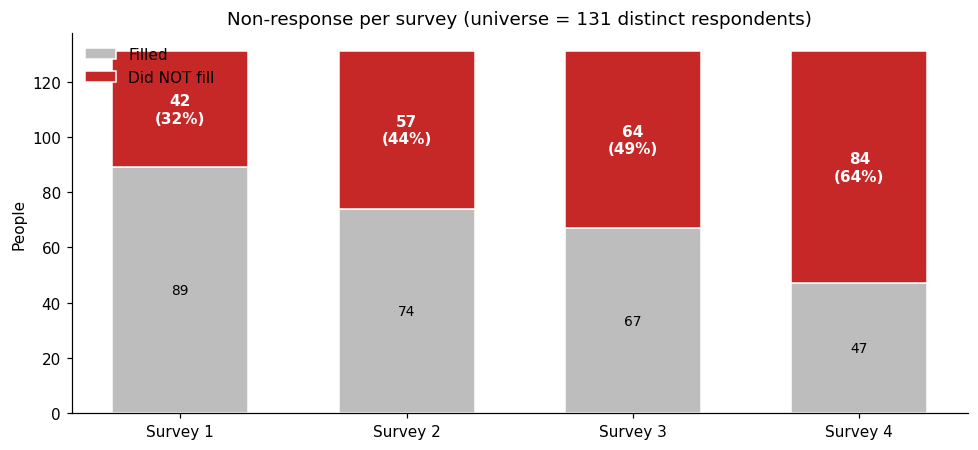

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.2))
n_surv = len(totals)
x = np.arange(n_surv)
w = 0.6

ax.bar(x, totals['Respondents'],  w, label='Filled',       color='#BDBDBD', edgecolor='white')
ax.bar(x, totals['Did NOT fill'], w, bottom=totals['Respondents'],
       label='Did NOT fill', color='#C62828', edgecolor='white')

for i, (filled, missed) in enumerate(zip(totals['Respondents'], totals['Did NOT fill'])):
    ax.text(i, filled + missed / 2, f'{missed}\n({missed/universe:.0%})',
            ha='center', va='center', color='white', fontweight='bold', fontsize=10)
    ax.text(i, filled / 2, f'{filled}', ha='center', va='center', color='black', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(totals.index)
ax.set_ylabel('People')
ax.set_ylim(0, universe * 1.05)
ax.set_title(f'Non-response per survey (universe = {universe} distinct respondents)')
ax.legend(frameon=False, loc='upper left')
plt.tight_layout()
plt.show()

## 4. Teamwise non-response

For each team: how many known members did NOT fill each survey.

In [7]:
team_size = master.groupby('team').size().rename('Team size')

team_missing = (~master[['in_S1', 'in_S2', 'in_S3', 'in_S4']]).groupby(master['team']).sum()
team_missing.columns = ['Missed S1', 'Missed S2', 'Missed S3', 'Missed S4']
team_missing = team_missing.astype(int)

team_info = (mapping.set_index('team')
             .reindex(team_size.index)
             .assign(**{'Team Name': lambda d: d['Team Name'].fillna('(no mapping)'),
                        'Team Room': lambda d: d['Team Room'].fillna('(no mapping)')}))

team_table = pd.concat([team_info, team_size, team_missing], axis=1)
team_table.index.name = 'Anon Team'
team_table = team_table.sort_index()
team_table

,Team Name,Team Room,Team size,Missed S1,Missed S2,Missed S3,Missed S4
Anon Team,,,,,,,
1,Woodmynd,1A,1,0,0,0,0
2,NDA_null,1B,11,5,5,5,5
3,Collective Voice,1C,8,2,3,2,5
4,PaNDA,1D,8,0,2,4,4
5,NU-Shift,1E,3,2,2,0,1
6,Scope2WBS,2A,6,0,2,3,2
11,Supply Wise,3A,13,7,7,7,10
12,The Envelope,3B,8,4,4,5,8
13,Route Awakening,3C,4,0,1,2,4


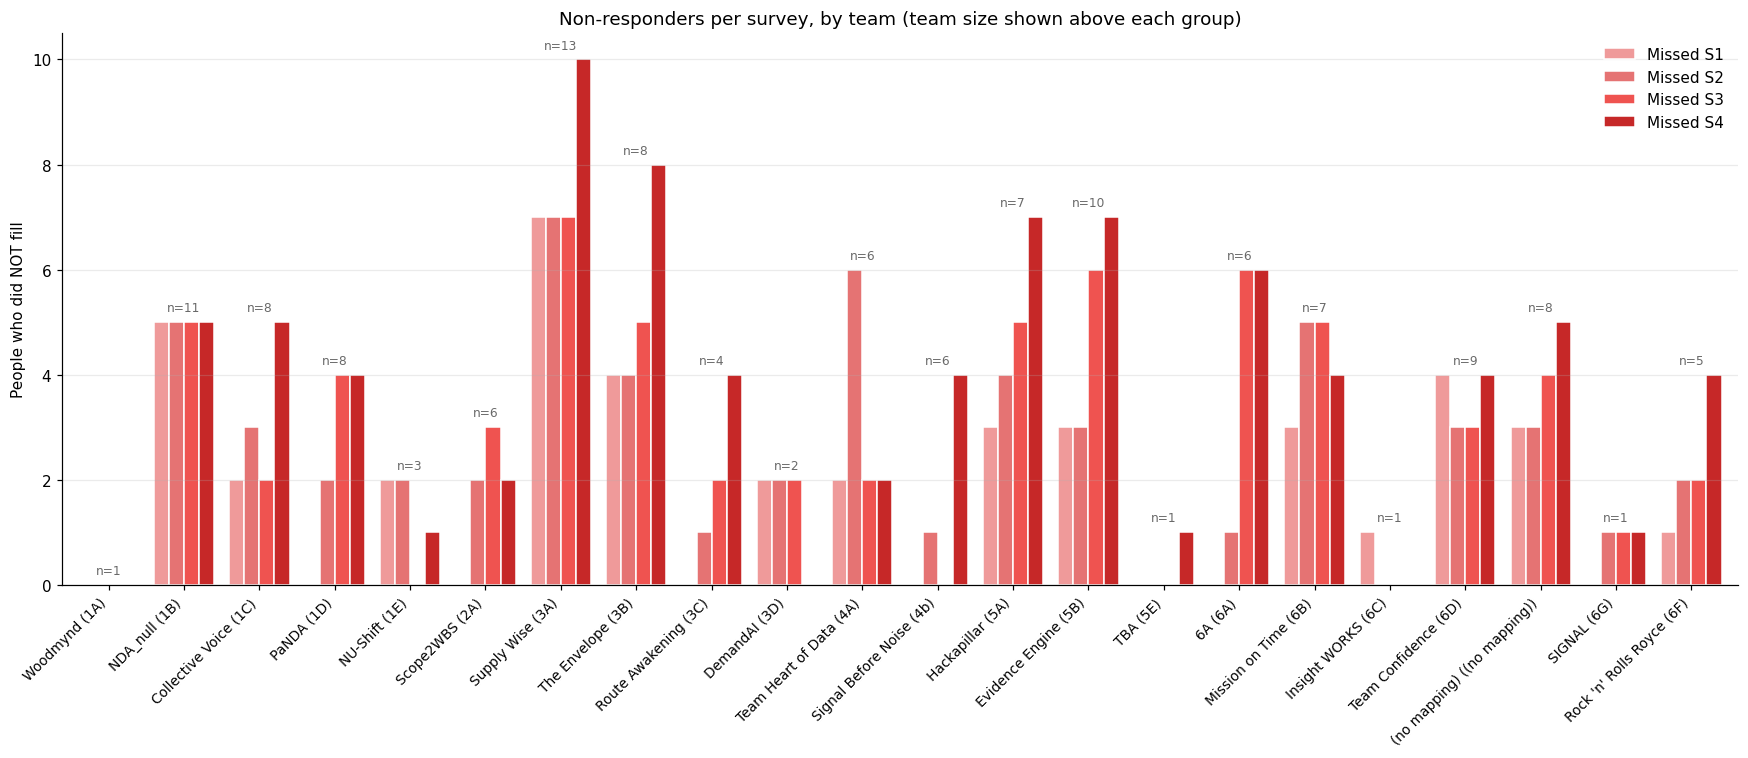

In [9]:
labels = [f"{team_table.loc[t, 'Team Name']} ({team_table.loc[t, 'Team Room']})"
          for t in team_table.index]

fig, ax = plt.subplots(figsize=(16, 7))
x = np.arange(len(team_table))
w = 0.2

reds = ['#EF9A9A', '#E57373', '#EF5350', '#C62828']
for i, (surv, colour) in enumerate(zip(['S1', 'S2', 'S3', 'S4'], reds)):
    offset = (i - 1.5) * w
    ax.bar(x + offset, team_table[f'Missed {surv}'], w,
           label=f'Missed {surv}', color=colour, edgecolor='white')

for i, (t, row) in enumerate(team_table.iterrows()):
    top = max(row['Missed S1'], row['Missed S2'], row['Missed S3'], row['Missed S4'])
    ax.text(i, top + 0.15, f"n={row['Team size']}", ha='center', va='bottom',
            fontsize=8, color='dimgrey')

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('People who did NOT fill')
ax.set_title('Non-responders per survey, by team (team size shown above each group)')
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.25)
ax.margins(x=0.01)
plt.tight_layout()
plt.show()

### Stacked view: filled vs did-not-fill per team per survey

Same data, presented so each team × survey bar shows the full team split. The red portion is the non-response; the grey portion gives the context of team size.

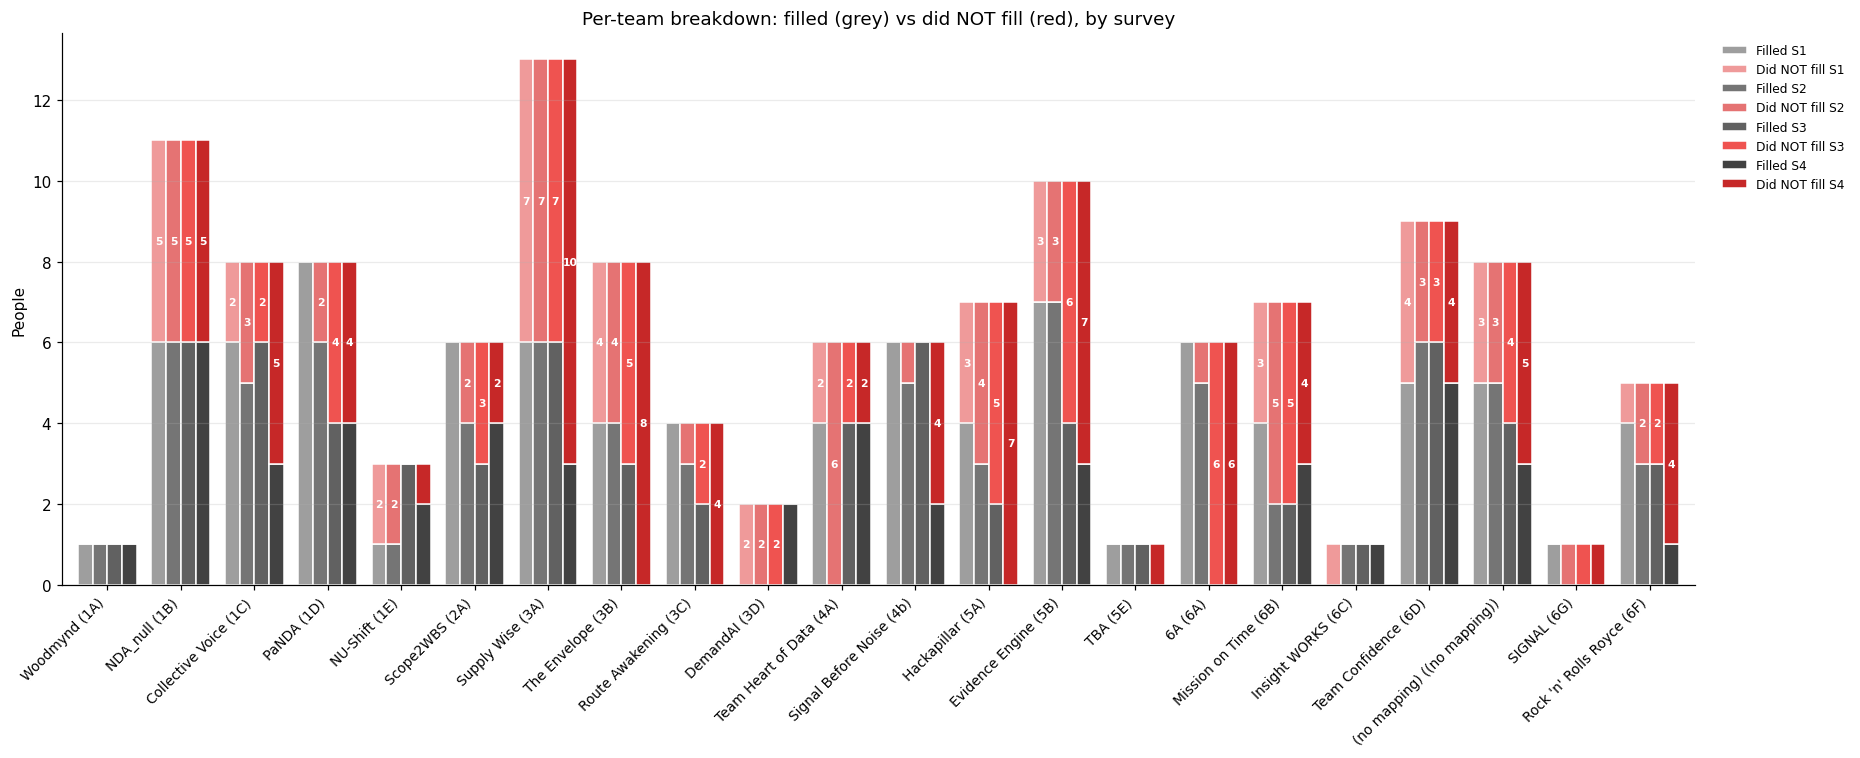

In [10]:
filled_tbl = pd.DataFrame(index=team_table.index)
for i in range(1, 5):
    filled_tbl[f'Filled S{i}'] = team_table['Team size'] - team_table[f'Missed S{i}']

labels = [f"{team_table.loc[t, 'Team Name']} ({team_table.loc[t, 'Team Room']})"
          for t in team_table.index]

fig, ax = plt.subplots(figsize=(17, 7))
x = np.arange(len(team_table))
w = 0.2

pairs = [
    ('S1', '#9E9E9E', '#EF9A9A'),
    ('S2', '#757575', '#E57373'),
    ('S3', '#616161', '#EF5350'),
    ('S4', '#424242', '#C62828'),
]
for i, (surv, colour_filled, colour_missed) in enumerate(pairs):
    offset = (i - 1.5) * w
    filled = filled_tbl[f'Filled {surv}'].values
    missed = team_table[f'Missed {surv}'].values
    ax.bar(x + offset, filled, w, color=colour_filled, edgecolor='white', label=f'Filled {surv}')
    ax.bar(x + offset, missed, w, bottom=filled, color=colour_missed, edgecolor='white',
           label=f'Did NOT fill {surv}')
    # Label the missed segment when it's tall enough to fit text (>= 2)
    for xi, (f_, m_) in enumerate(zip(filled, missed)):
        if m_ >= 2:
            ax.text(xi + offset, f_ + m_ / 2, str(m_), ha='center', va='center',
                    fontsize=7, color='white', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('People')
ax.set_title('Per-team breakdown: filled (grey) vs did NOT fill (red), by survey')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', frameon=False, fontsize=8, ncol=1)
ax.grid(axis='y', alpha=0.25)
ax.margins(x=0.01)
plt.tight_layout()
plt.show()

### Non-response rate heatmap

Fraction of each team's known members who did NOT fill each survey. Dark red = high non-response.

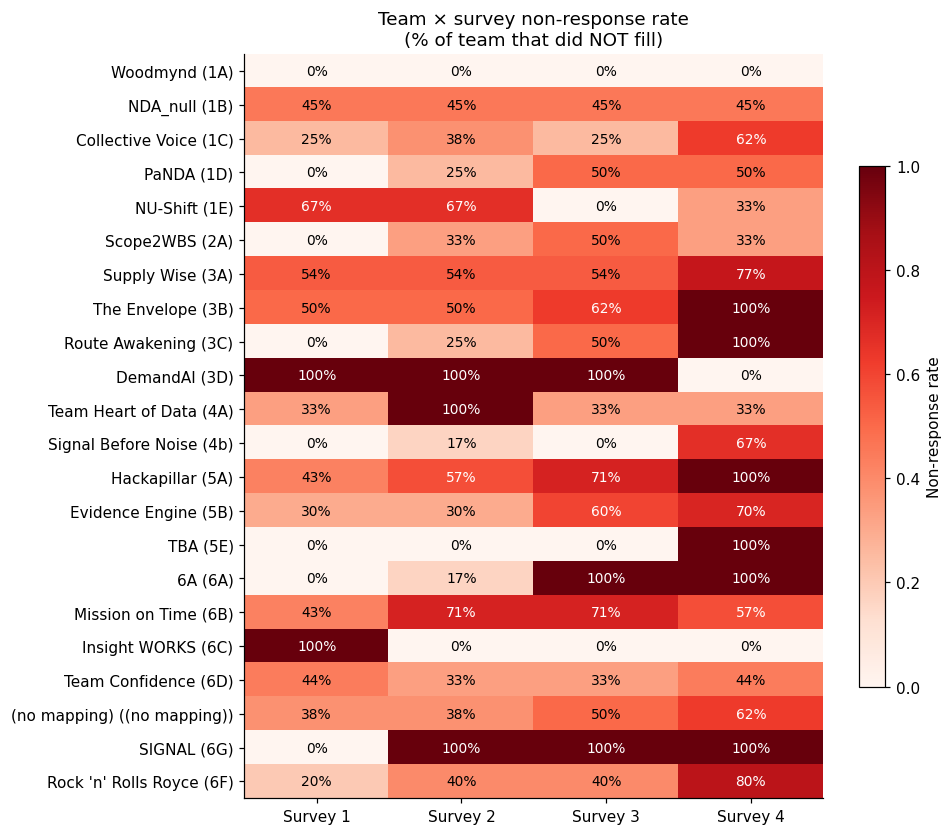

In [11]:
miss_rate = team_table[['Missed S1', 'Missed S2', 'Missed S3', 'Missed S4']].div(team_table['Team size'], axis=0)
miss_rate.columns = ['Survey 1', 'Survey 2', 'Survey 3', 'Survey 4']

row_labels = [f"{team_table.loc[t, 'Team Name'][:22]} ({team_table.loc[t, 'Team Room']})"
              for t in miss_rate.index]

fig, ax = plt.subplots(figsize=(9, max(4, 0.35 * len(miss_rate))))
im = ax.imshow(miss_rate.values, cmap='Reds', vmin=0, vmax=1, aspect='auto')

ax.set_xticks(range(miss_rate.shape[1]))
ax.set_xticklabels(miss_rate.columns)
ax.set_yticks(range(len(miss_rate)))
ax.set_yticklabels(row_labels)

for i in range(len(miss_rate)):
    for j in range(miss_rate.shape[1]):
        val = miss_rate.values[i, j]
        ax.text(j, i, f'{val:.0%}', ha='center', va='center',
                color='white' if val > 0.55 else 'black', fontsize=9)

plt.colorbar(im, ax=ax, label='Non-response rate', shrink=0.7)
ax.set_title('Team \u00d7 survey non-response rate\n(% of team that did NOT fill)')
plt.tight_layout()
plt.show()

## 5. Overlap between surveys

All seven regions of the three-way Venn.

In [12]:
s1, s2, s3, s4 = (master['in_S1'], master['in_S2'], master['in_S3'], master['in_S4'])

# All 15 non-empty subsets of {S1, S2, S3, S4}
from itertools import combinations
flags = {'S1': s1, 'S2': s2, 'S3': s3, 'S4': s4}
all_names = list(flags)

regions = {}
for r in range(1, 5):
    for combo in combinations(all_names, r):
        # mask = filled all surveys in combo AND not in the others
        mask = np.ones(len(master), dtype=bool)
        for name in all_names:
            mask &= (flags[name].values if name in combo else ~flags[name].values)
        label = ' & '.join(combo) + (' only' if r < 4 else '')
        regions[label] = int(mask.sum())

regions_df = pd.Series(regions, name='Respondents').to_frame()
regions_df['% of universe'] = (regions_df['Respondents'] / universe * 100).round(1)
regions_df = regions_df.sort_values('Respondents', ascending=False)
regions_df.loc['TOTAL'] = [regions_df['Respondents'].sum(), round(regions_df['% of universe'].sum(), 1)]
regions_df

,Respondents,% of universe
S1 only,21.0,16.0
S1 & S2 & S3 & S4,21.0,16.0
S1 & S2 only,20.0,15.3
S1 & S2 & S3 only,15.0,11.5
S2 only,12.0,9.2
S3 only,10.0,7.6
S3 & S4 only,9.0,6.9
S4 only,8.0,6.1
S1 & S3 only,5.0,3.8
S1 & S3 & S4 only,4.0,3.1


In [13]:
# Pairwise "filled X but not Y" counts — useful for diagnosing where drop-off happens.
focus = pd.Series({
    'Filled S1 but NOT S2':  ( s1 & ~s2).sum(),
    'Filled S1 but NOT S3':  ( s1 & ~s3).sum(),
    'Filled S1 but NOT S4':  ( s1 & ~s4).sum(),
    'Filled S2 but NOT S3':  ( s2 & ~s3).sum(),
    'Filled S2 but NOT S4':  ( s2 & ~s4).sum(),
    'Filled S3 but NOT S4':  ( s3 & ~s4).sum(),
    'Filled all four':       ( s1 &  s2 &  s3 &  s4).sum(),
    'Filled none of the four': (~s1 & ~s2 & ~s3 & ~s4).sum(),
}, name='Respondents').to_frame()
focus

,Respondents
Filled S1 but NOT S2,30
Filled S1 but NOT S3,44
Filled S1 but NOT S4,61
Filled S2 but NOT S3,35
Filled S2 but NOT S4,48
Filled S3 but NOT S4,31
Filled all four,21
Filled none of the four,0


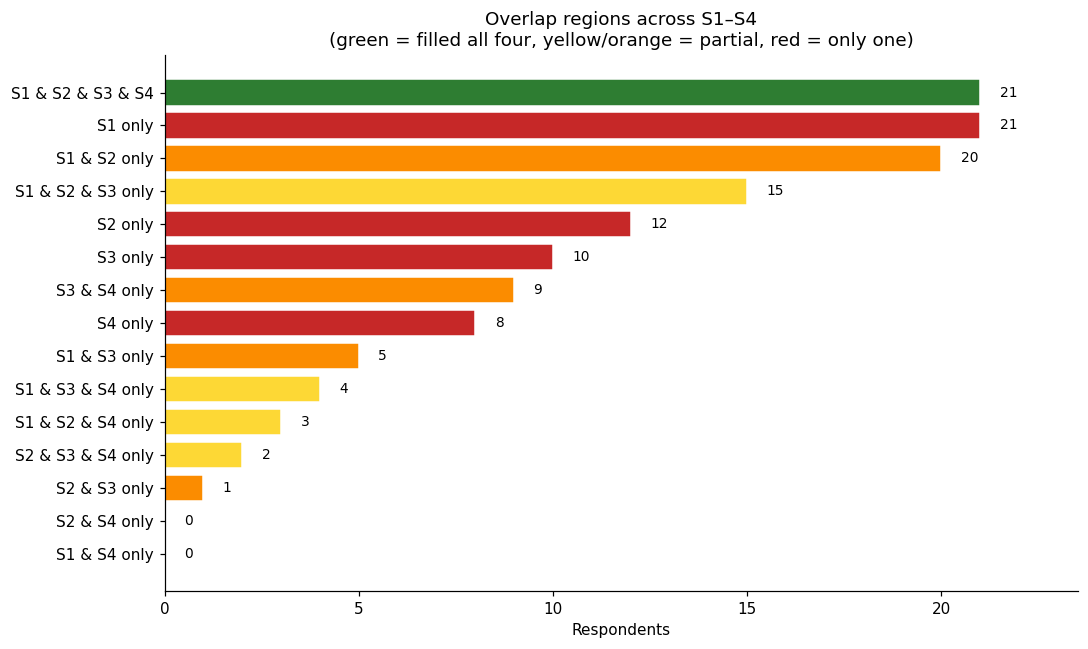

In [14]:
# A 4-set Venn is hard to read, so we use an UpSet-style horizontal bar chart:
# each row is one intersection region, bar length = number of people in that region.
region_plot = regions_df.drop('TOTAL').sort_values('Respondents', ascending=True)

fig, ax = plt.subplots(figsize=(10, max(5, 0.4 * len(region_plot))))
# Colour bars by number of surveys in the intersection: all-four green, singletons red.
def _region_colour(label):
    n = label.replace(' only', '').count('&') + 1
    return {1: '#C62828', 2: '#FB8C00', 3: '#FDD835', 4: '#2E7D32'}.get(n, '#888')
colors = [_region_colour(lbl) for lbl in region_plot.index]
bars = ax.barh(region_plot.index, region_plot['Respondents'], color=colors, edgecolor='white')

for bar, v_ in zip(bars, region_plot['Respondents']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{int(v_)}', va='center', fontsize=9)

ax.set_xlabel('Respondents')
ax.set_title('Overlap regions across S1\u2013S4\n(green = filled all four, yellow/orange = partial, red = only one)')
ax.set_xlim(0, region_plot['Respondents'].max() * 1.12)
plt.tight_layout()
plt.show()

## 6. Per-team attrition patterns

How each team's known members break down by which surveys they missed. Green = filled all three; reds = missed one or more waves.

In [15]:
def pattern(row):
    return ''.join(['1' if row[f'in_S{i}'] else '0' for i in range(1, 5)])

master['pattern'] = master.apply(pattern, axis=1)

def pattern_label(p):
    surveys_filled = [f'S{i+1}' for i, b in enumerate(p) if b == '1']
    surveys_missed = [f'S{i+1}' for i, b in enumerate(p) if b == '0']
    if not surveys_missed:
        return 'All four'
    if not surveys_filled:
        return 'Filled none'
    if len(surveys_missed) == 1:
        return f'Missed {surveys_missed[0]} only'
    return f'Missed {" & ".join(surveys_missed)}'

master['pattern_label'] = master['pattern'].map(pattern_label)

pivot = master.pivot_table(index='team', columns='pattern_label', values='Rater',
                           aggfunc='count', fill_value=0)

# Sort columns: "All four" first, then by number of surveys missed ascending, then alphabetical
def _sort_key(c):
    if c == 'All four': return (0, '')
    if c == 'Filled none': return (99, '')
    n_missed = c.count('&') + 1 if 'Missed' in c else 0
    return (n_missed, c)
pivot = pivot.reindex(columns=sorted(pivot.columns, key=_sort_key))

pivot_display = pivot.copy()
pivot_display.insert(0, 'Team Name', [team_table.loc[t, 'Team Name'] for t in pivot_display.index])
pivot_display.insert(1, 'Team Room', [team_table.loc[t, 'Team Room'] for t in pivot_display.index])
pivot_display

pattern_label,Team Name,Team Room,All four,Missed S1 only,Missed S2 only,Missed S3 only,Missed S4 only,Missed S1 & S2,Missed S1 & S4,Missed S2 & S4,Missed S3 & S4,Missed S1 & S2 & S3,Missed S1 & S2 & S4,Missed S1 & S3 & S4,Missed S2 & S3 & S4
team,,,,,,,,,,,,,,,
1,Woodmynd,1A,1,0,0,0,0,0,0,0,0,0,0,0,0
2,NDA_null,1B,4,0,0,0,0,1,0,0,0,1,1,2,2
3,Collective Voice,1C,2,0,0,0,1,1,0,2,1,0,0,1,0
4,PaNDA,1D,3,0,0,1,1,0,0,0,1,0,0,0,2
5,NU-Shift,1E,0,0,1,0,0,1,1,0,0,0,0,0,0
6,Scope2WBS,2A,3,0,0,1,0,0,0,0,0,0,0,0,2
11,Supply Wise,3A,2,0,0,0,0,0,0,0,2,1,4,2,2
12,The Envelope,3B,0,0,0,0,1,0,0,0,1,0,2,2,2
13,Route Awakening,3C,0,0,0,0,1,0,0,1,2,0,0,0,0


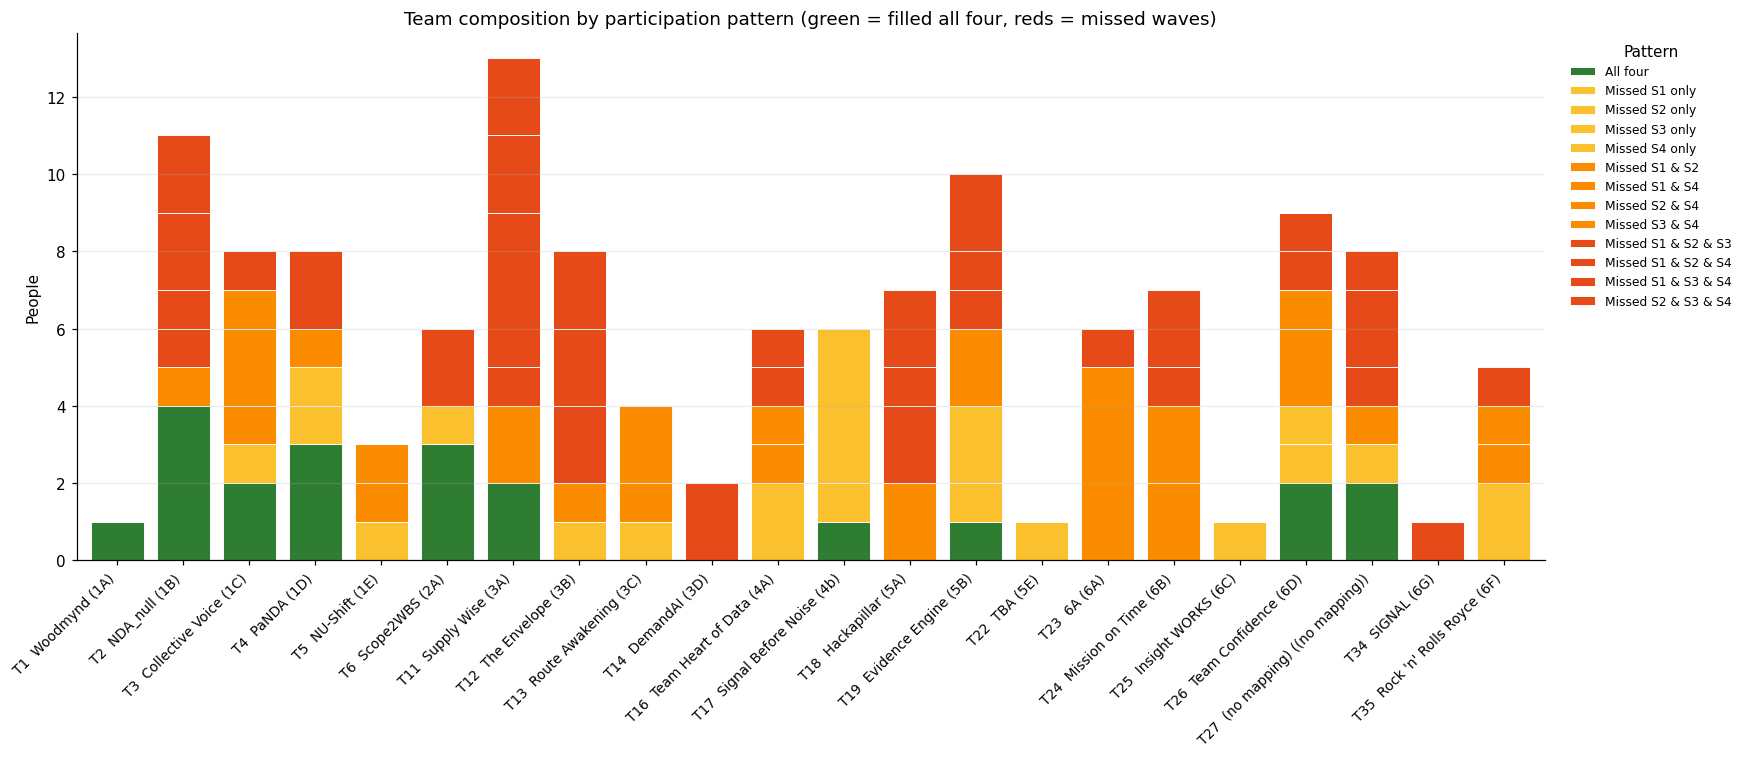

In [16]:
# Colour scheme: green for "all four", warm/yellow for one miss, oranges for two, reds for three, dark red for all missed.
def _pattern_colour(label):
    if label == 'All four':    return '#2E7D32'
    if label == 'Filled none': return '#000000'
    n_missed = label.count('&') + 1 if 'Missed' in label else 0
    return {1: '#FBC02D', 2: '#FB8C00', 3: '#E64A19', 4: '#B71C1C'}.get(n_missed, '#888')

plot_cols = list(pivot.columns)
labels = [f"T{t}  {team_table.loc[t, 'Team Name']} ({team_table.loc[t, 'Team Room']})"
          for t in pivot.index]

fig, ax = plt.subplots(figsize=(16, 7))
bottom = np.zeros(len(pivot))
x = np.arange(len(pivot))
for col in plot_cols:
    ax.bar(x, pivot[col].values, bottom=bottom, label=col,
           color=_pattern_colour(col), edgecolor='white', linewidth=0.6)
    bottom += pivot[col].values

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('People')
ax.set_title('Team composition by participation pattern (green = filled all four, reds = missed waves)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', frameon=False, title='Pattern', fontsize=8)
ax.grid(axis='y', alpha=0.25)
ax.margins(x=0.01)
plt.tight_layout()
plt.show()

## 7. Summary

In [17]:
lines = [
    f"Universe: {universe} distinct respondents across all four surveys",
    '',
]
for i in range(1, 5):
    col = master[f'in_S{i}']
    lines.append(f"Did NOT fill Survey {i}: {(~col).sum():>3}  ({(~col).sum()/universe:.0%} of universe)")
lines += [
    '',
    'Key overlap regions:',
    f"  Filled all four:              {( s1 &  s2 &  s3 &  s4).sum()}",
    f"  Filled S1 only:               {( s1 & ~s2 & ~s3 & ~s4).sum()}",
    f"  Filled S4 only:               {(~s1 & ~s2 & ~s3 &  s4).sum()}",
    f"  Filled S1,S2 but neither S3,S4: {( s1 &  s2 & ~s3 & ~s4).sum()}  (Day 1 only)",
    f"  Filled S3,S4 but neither S1,S2: {(~s1 & ~s2 &  s3 &  s4).sum()}  (Day 2 only)",
    '',
    'Worst-performing teams by non-response rate (avg across all four surveys):',
]
avg_miss = miss_rate.mean(axis=1).sort_values(ascending=False).head(5)
for t, rate in avg_miss.items():
    name = team_table.loc[t, 'Team Name']
    room = team_table.loc[t, 'Team Room']
    lines.append(f"  T{t} {name} ({room}): {rate:.0%} avg non-response")
print('\n'.join(lines))

Universe: 131 distinct respondents across all four surveys

Did NOT fill Survey 1:  42  (32% of universe)
Did NOT fill Survey 2:  57  (44% of universe)
Did NOT fill Survey 3:  64  (49% of universe)
Did NOT fill Survey 4:  84  (64% of universe)

Key overlap regions:
  Filled all four:              21
  Filled S1 only:               21
  Filled S4 only:               8
  Filled S1,S2 but neither S3,S4: 20  (Day 1 only)
  Filled S3,S4 but neither S1,S2: 9  (Day 2 only)

Worst-performing teams by non-response rate (avg across all four surveys):
  T34 SIGNAL (6G): 75% avg non-response
  T14 DemandAI (3D): 75% avg non-response
  T18 Hackapillar (5A): 68% avg non-response
  T12 The Envelope (3B): 66% avg non-response
  T24 Mission on Time (6B): 61% avg non-response


## 8. Export

In [ ]:
master.to_csv('respondent_participation.csv', index=False)
team_table.to_csv('team_non_response_counts.csv')
pivot_display.to_csv('team_participation_patterns.csv')
print('Wrote: respondent_participation.csv, team_non_response_counts.csv, team_participation_patterns.csv')

Wrote: respondent_participation.csv, team_non_response_counts.csv, team_participation_patterns.csv


,Day,Participants,Filled,Did NOT fill,Response rate
Survey 1,Day 1,112,89,23,79%
Survey 2,Day 1,112,74,38,66%
Survey 3,Day 2,108,67,41,62%
Survey 4,Day 2,108,47,61,44%


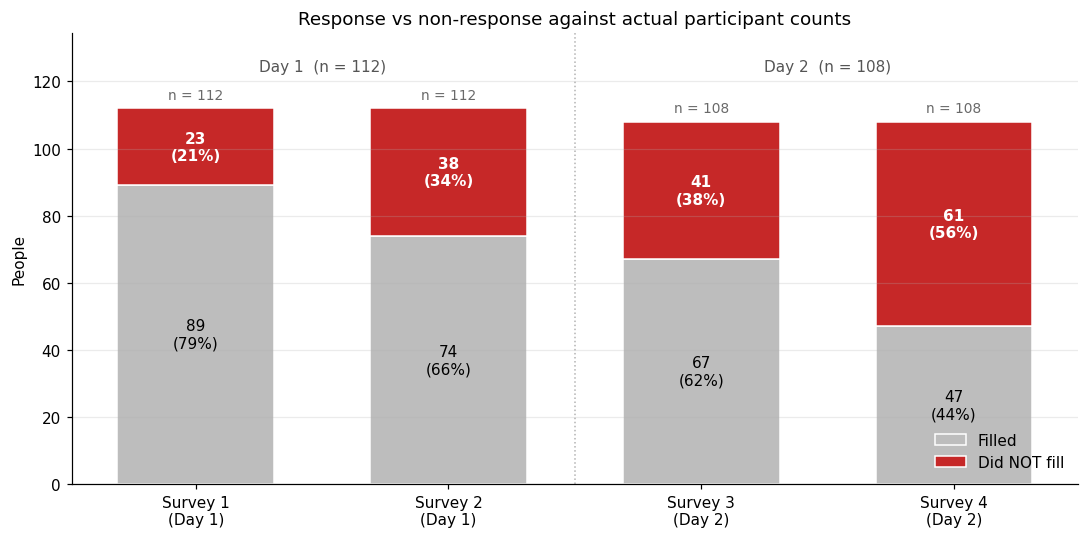

In [18]:
# --- Response vs true participant counts across both days ---
# S1 and S2 were on Day 1 with 112 participants in the room.
# S3 and S4 were on Day 2 with 108 participants.

PARTICIPANTS = {'S1': 112, 'S2': 112, 'S3': 108, 'S4': 108}
DAY = {'S1': 'Day 1', 'S2': 'Day 1', 'S3': 'Day 2', 'S4': 'Day 2'}

keys = ['S1', 'S2', 'S3', 'S4']
resp = {k: surveys[k]['Rater'].nunique() for k in keys}
miss = {k: PARTICIPANTS[k] - resp[k] for k in keys}
rate = {k: resp[k] / PARTICIPANTS[k] for k in keys}

summary = pd.DataFrame({
    'Day':          [DAY[k] for k in keys],
    'Participants': [PARTICIPANTS[k] for k in keys],
    'Filled':       [resp[k] for k in keys],
    'Did NOT fill': [miss[k] for k in keys],
    'Response rate':[f'{rate[k]:.0%}' for k in keys],
}, index=[f'Survey {i+1}' for i in range(len(keys))])
display(summary)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(keys))
w = 0.62
labels = [f'Survey {i+1}\n({DAY[k]})' for i, k in enumerate(keys)]

filled_vals = [resp[k] for k in keys]
missed_vals = [miss[k] for k in keys]
denom_vals  = [PARTICIPANTS[k] for k in keys]

ax.bar(x, filled_vals, w, color='#BDBDBD', edgecolor='white', label='Filled')
ax.bar(x, missed_vals, w, bottom=filled_vals, color='#C62828', edgecolor='white', label='Did NOT fill')

for i, (f_, m_, n_) in enumerate(zip(filled_vals, missed_vals, denom_vals)):
    ax.text(i, f_ / 2, f'{f_}\n({f_/n_:.0%})',
            ha='center', va='center', fontsize=10, color='black')
    ax.text(i, f_ + m_ / 2, f'{m_}\n({m_/n_:.0%})',
            ha='center', va='center', fontsize=10, color='white', fontweight='bold')
    ax.text(i, n_ + 2, f'n = {n_}', ha='center', va='bottom', fontsize=9, color='dimgrey')

# Visual separator between the two days (after S2)
ax.axvline(1.5, color='grey', linestyle=':', linewidth=1, alpha=0.6)
ax.text(0.5, max(denom_vals) * 1.1, 'Day 1  (n = 112)', ha='center', fontsize=10, color='#555')
ax.text(2.5, max(denom_vals) * 1.1, 'Day 2  (n = 108)', ha='center', fontsize=10, color='#555')

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('People')
ax.set_ylim(0, max(denom_vals) * 1.2)
ax.set_title('Response vs non-response against actual participant counts')
ax.legend(frameon=False, loc='lower right')
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

In [19]:
# Team-level scores from Survey 1 respondents, used as a BASELINE.
# Rationale: S1 is the earliest wave, so these values are a "before" snapshot
# that precedes most of the non-response events in later surveys.

S1_WELL = 'Wellbeing'
S1_COG  = 'My level of <b>cognitive</b> load&nbsp;'

s1_raw = surveys['S1'][['Rater', 'team', S1_WELL, S1_COG]].copy()
s1_raw[S1_WELL] = pd.to_numeric(s1_raw[S1_WELL], errors='coerce')
s1_raw[S1_COG]  = pd.to_numeric(s1_raw[S1_COG],  errors='coerce')

team_scores = s1_raw.groupby('team').agg(
    s1_wellbeing_mean=(S1_WELL, 'mean'),
    s1_cogload_mean=(S1_COG, 'mean'),
    s1_n=(S1_WELL, 'count'),
).round(2)

team_analysis = team_table.join(team_scores, how='left')
for i in (2, 3, 4):
    team_analysis[f'Non-response rate S{i}'] = (team_analysis[f'Missed S{i}'] / team_analysis['Team size']).round(3)

team_analysis['Challenge'] = team_analysis.index.map(
    mapping_raw.dropna(subset=['Anon Team']).assign(t=lambda d: d['Anon Team'].astype(int))
    .set_index('t')['Challenge Number']
).astype('Int64')

team_analysis[['Team Name', 'Team Room', 'Challenge', 'Team size',
               's1_wellbeing_mean', 's1_cogload_mean', 's1_n',
               'Missed S2', 'Missed S3', 'Missed S4',
               'Non-response rate S2', 'Non-response rate S3', 'Non-response rate S4']]

,Team Name,Team Room,Challenge,Team size,s1_wellbeing_mean,s1_cogload_mean,s1_n,Missed S2,Missed S3,Missed S4,Non-response rate S2,Non-response rate S3,Non-response rate S4
Anon Team,,,,,,,,,,,,,
1,Woodmynd,1A,1,1,78.00,58.00,1.0,0,0,0,0.000,0.000,0.000
2,NDA_null,1B,1,11,48.50,64.00,6.0,5,5,5,0.455,0.455,0.455
3,Collective Voice,1C,1,8,76.33,69.17,6.0,3,2,5,0.375,0.250,0.625
4,PaNDA,1D,1,8,55.88,56.50,8.0,2,4,4,0.250,0.500,0.500
5,NU-Shift,1E,5,3,90.00,67.00,1.0,2,0,1,0.667,0.000,0.333
6,Scope2WBS,2A,2,6,53.67,74.00,6.0,2,3,2,0.333,0.500,0.333
11,Supply Wise,3A,3,13,57.83,56.50,6.0,7,7,10,0.538,0.538,0.769
12,The Envelope,3B,3,8,84.25,72.00,4.0,4,5,8,0.500,0.625,1.000
13,Route Awakening,3C,3,4,79.75,63.50,4.0,1,2,4,0.250,0.500,1.000


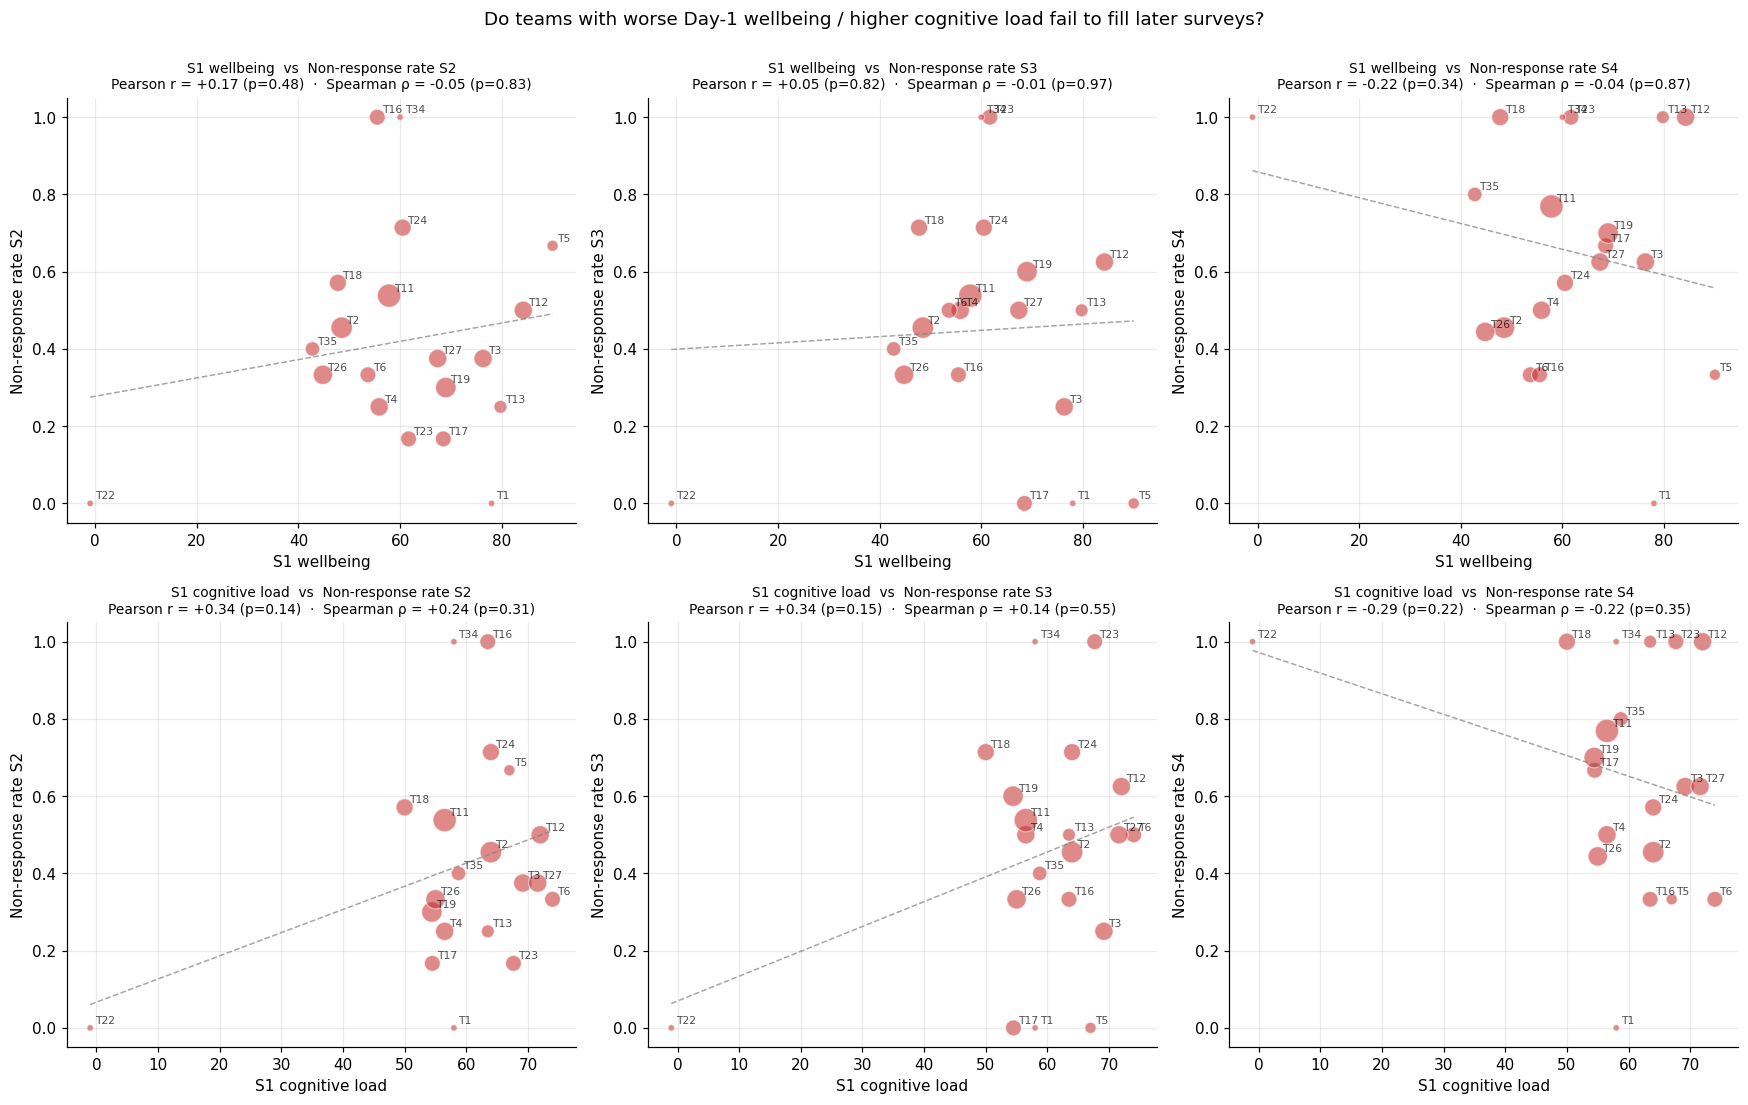


Teams in analysis: 20 (dot size = team size)


In [20]:
from scipy import stats

# Drop teams where we don't have an S1 baseline (nobody from that team filled S1)
corr_df = team_analysis.dropna(subset=['s1_wellbeing_mean', 's1_cogload_mean']).copy()

pairs = []
for xcol, xlab in [('s1_wellbeing_mean', 'S1 wellbeing'),
                   ('s1_cogload_mean',   'S1 cognitive load')]:
    for i in (2, 3, 4):
        pairs.append((xcol, f'Non-response rate S{i}', xlab, f'Non-response rate S{i}'))

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, (xcol, ycol, xlab, ylab) in zip(axes.flat, pairs):
    d = corr_df[[xcol, ycol, 'Team size']].dropna()
    x_vals = d[xcol].values
    y_vals = d[ycol].values

    r_p, p_p = stats.pearsonr(x_vals, y_vals)
    r_s, p_s = stats.spearmanr(x_vals, y_vals)

    ax.scatter(x_vals, y_vals, s=d['Team size'] * 18, alpha=0.55,
               color='#C62828', edgecolor='white', linewidth=0.8)
    for t, row in d.iterrows():
        ax.annotate(f'T{t}', (row[xcol], row[ycol]),
                    fontsize=7, alpha=0.7, xytext=(3, 3), textcoords='offset points')

    if len(x_vals) >= 3:
        slope, intercept = np.polyfit(x_vals, y_vals, 1)
        xs = np.linspace(x_vals.min(), x_vals.max(), 50)
        ax.plot(xs, slope * xs + intercept, color='grey', linestyle='--', linewidth=1, alpha=0.7)

    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    ax.set_title(f'{xlab}  vs  {ylab}\n'
                 f'Pearson r = {r_p:+.2f} (p={p_p:.2f})  \u00b7  Spearman \u03c1 = {r_s:+.2f} (p={p_s:.2f})',
                 fontsize=9)
    ax.grid(alpha=0.25)

plt.suptitle('Do teams with worse Day-1 wellbeing / higher cognitive load fail to fill later surveys?',
             fontsize=12, y=1.00)
plt.tight_layout()
plt.show()

print(f'\nTeams in analysis: {len(corr_df)} (dot size = team size)')

Teams per challenge:
  Challenge 1: 4 team(s)
  Challenge 2: 1 team(s)
  Challenge 3: 4 team(s)
  Challenge 4: 2 team(s)
  Challenge 5: 4 team(s)
  Challenge 6: 6 team(s)


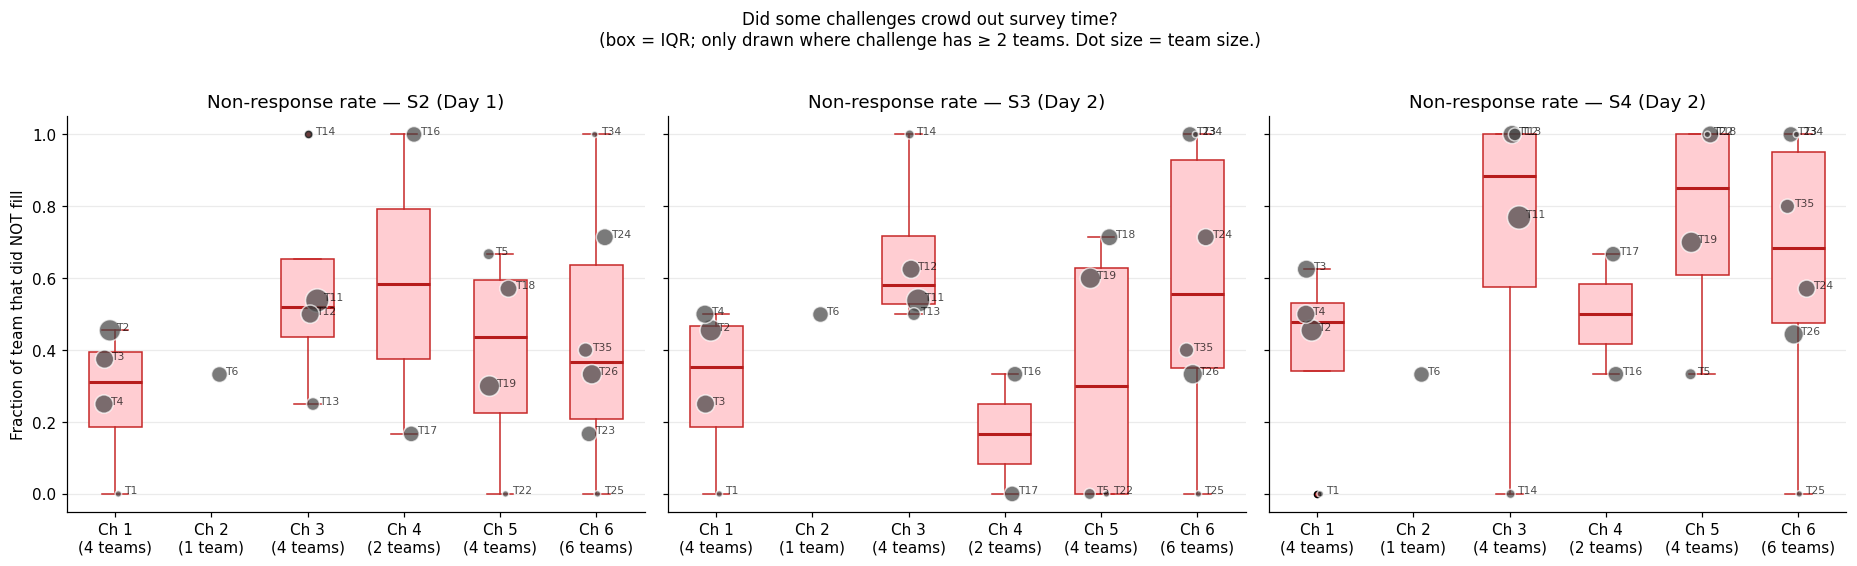

Kruskal-Wallis across challenges — S2 non-response: H=1.84, p=0.764
Kruskal-Wallis across challenges — S3 non-response: H=5.37, p=0.252
Kruskal-Wallis across challenges — S4 non-response: H=3.28, p=0.512


In [21]:
# Challenge is categorical (6 groups, uneven team counts) — comparison not correlation.
# Boxplot + individual team points for transparency. Now showing S2, S3, and S4 side by side.

challenge_counts = team_analysis['Challenge'].value_counts().sort_index()
print('Teams per challenge:')
for c, n in challenge_counts.items():
    print(f'  Challenge {c}: {n} team(s)')

fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)

target_surveys = [
    ('Non-response rate S2', 'S2 (Day 1)'),
    ('Non-response rate S3', 'S3 (Day 2)'),
    ('Non-response rate S4', 'S4 (Day 2)'),
]

for ax, (ycol, title) in zip(axes, target_surveys):
    d = team_analysis[['Challenge', ycol, 'Team size']].dropna()
    challenges = sorted(d['Challenge'].unique())
    data_by_ch = [d.loc[d['Challenge'] == c, ycol].values for c in challenges]

    bp_data = [vals for vals, c in zip(data_by_ch, challenges) if len(vals) >= 2]
    bp_pos  = [i for i, (vals, c) in enumerate(zip(data_by_ch, challenges)) if len(vals) >= 2]
    if bp_data:
        ax.boxplot(bp_data, positions=bp_pos, widths=0.55, patch_artist=True,
                   boxprops=dict(facecolor='#FFCDD2', edgecolor='#C62828'),
                   medianprops=dict(color='#B71C1C', linewidth=2),
                   whiskerprops=dict(color='#C62828'),
                   capprops=dict(color='#C62828'),
                   flierprops=dict(marker='o', markerfacecolor='#C62828', markersize=4))

    rng = np.random.default_rng(0)
    for i, (vals, c) in enumerate(zip(data_by_ch, challenges)):
        if len(vals) == 0:
            continue
        sizes = d.loc[d['Challenge'] == c, 'Team size'].values * 18
        jitter = rng.uniform(-0.12, 0.12, size=len(vals))
        ax.scatter(np.full(len(vals), i) + jitter, vals, s=sizes,
                   color='#424242', alpha=0.7, edgecolor='white', zorder=3)
        teams_here = d.loc[d['Challenge'] == c].index.tolist()
        for xj, yj, tj in zip(np.full(len(vals), i) + jitter, vals, teams_here):
            ax.annotate(f'T{tj}', (xj, yj), fontsize=7, alpha=0.7,
                        xytext=(4, 0), textcoords='offset points')

    ax.set_xticks(range(len(challenges)))
    ax.set_xticklabels([f'Ch {c}\n({challenge_counts[c]} team{"s" if challenge_counts[c] > 1 else ""})'
                        for c in challenges])
    ax.set_ylabel('Fraction of team that did NOT fill' if ax is axes[0] else '')
    ax.set_title(f'Non-response rate \u2014 {title}')
    ax.set_ylim(-0.05, 1.05)
    ax.grid(axis='y', alpha=0.25)

plt.suptitle('Did some challenges crowd out survey time?\n'
             '(box = IQR; only drawn where challenge has \u2265 2 teams. Dot size = team size.)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

# Kruskal-Wallis across challenges with >= 2 teams
from scipy.stats import kruskal
for ycol, label in [('Non-response rate S2', 'S2'),
                    ('Non-response rate S3', 'S3'),
                    ('Non-response rate S4', 'S4')]:
    groups = [team_analysis.loc[team_analysis['Challenge'] == c, ycol].dropna().values
              for c in sorted(team_analysis['Challenge'].dropna().unique())]
    groups = [g for g in groups if len(g) >= 2]
    if len(groups) >= 2:
        h, p = kruskal(*groups)
        print(f'Kruskal-Wallis across challenges \u2014 {label} non-response: H={h:.2f}, p={p:.3f}')

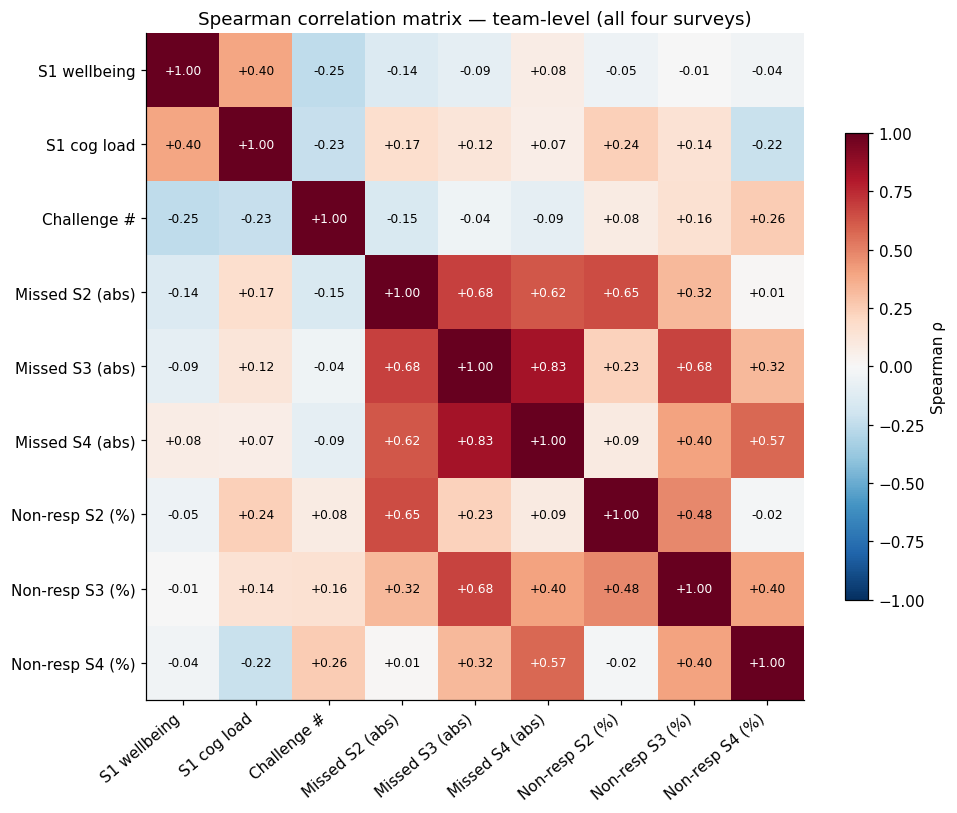


Interpretation guide:
  Spearman ρ > 0: teams with higher X tend to have higher Y (rank-wise)
  |ρ| < 0.3   weak    · 0.3-0.5 moderate · > 0.5 strong
  With n ≈ 19 teams, ρ needs to be ~|0.43|+ for p < 0.05


In [22]:
# Everything together in one heatmap for quick reference
corr_vars = team_analysis[['s1_wellbeing_mean', 's1_cogload_mean', 'Challenge',
                           'Missed S2', 'Missed S3', 'Missed S4',
                           'Non-response rate S2', 'Non-response rate S3', 'Non-response rate S4']].copy()
corr_vars = corr_vars.rename(columns={
    's1_wellbeing_mean': 'S1 wellbeing',
    's1_cogload_mean':   'S1 cog load',
    'Challenge':         'Challenge #',
    'Missed S2':         'Missed S2 (abs)',
    'Missed S3':         'Missed S3 (abs)',
    'Missed S4':         'Missed S4 (abs)',
    'Non-response rate S2': 'Non-resp S2 (%)',
    'Non-response rate S3': 'Non-resp S3 (%)',
    'Non-response rate S4': 'Non-resp S4 (%)',
})

corr = corr_vars.corr(method='spearman')

fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=40, ha='right')
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.index)
for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:+.2f}', ha='center', va='center',
                    color='white' if abs(v) > 0.55 else 'black', fontsize=8)
plt.colorbar(im, ax=ax, label='Spearman \u03c1', shrink=0.7)
ax.set_title('Spearman correlation matrix \u2014 team-level (all four surveys)')
plt.tight_layout()
plt.show()

print('\nInterpretation guide:')
print('  Spearman \u03c1 > 0: teams with higher X tend to have higher Y (rank-wise)')
print('  |\u03c1| < 0.3   weak    \u00b7 0.3-0.5 moderate \u00b7 > 0.5 strong')
print(f'  With n \u2248 {len(corr_vars.dropna())} teams, \u03c1 needs to be ~|0.43|+ for p < 0.05')